In [1]:
from decontamination_classes import TPMProcessor
from decontamination_classes import CrossContaminationDetector
from decontamination_classes import ThresholdFiltrator
import numpy as np
import pandas as pd

### Potential cross-contamination was inferred from strong TPM asymmetry between highly similar transcript pairs identified by BLASTn.

##### Load TPM tables for all three species and aggregate transcript expression values using maximal TPM across body segments.

In [4]:
processor = TPMProcessor(['../demodata/Amar_log2_av_tpm.txt', '../demodata/Pele_log2_av_tpm.txt', '../demodata/Pdum_log2_av_tpm.txt'])
df = processor()
print(df)

                    contigs  tpm_value
0            Amar_DN0_c0_g1   1.020642
1          Amar_DN100_c0_g1   2.591633
2        Amar_DN10000_c0_g1   1.008854
3       Amar_DN100002_c0_g1   1.124948
4       Amar_DN100006_c0_g1   0.327499
...                     ...        ...
764409   Pdum_DN99990_c0_g2   0.815560
764410   Pdum_DN99992_c0_g1   1.038648
764411   Pdum_DN99999_c0_g1   0.953788
764412   Pdum_DN99999_c0_g2   0.385670
764413   Pdum_DN99999_c1_g1   0.556818

[764414 rows x 2 columns]


##### Load highly similar transcript pairs identified by BLASTn and calculate log2 TPM ratios between transcripts in order to estimate potential cross-contamination.

In [5]:
contig_pairs = pd.read_csv("../demodata/unique_pairs_clean_notrinity.tsv", sep='\t', header=None)
contig_pairs.columns = ['pot_host1', 'pot_host2']

detector = CrossContaminationDetector(contig_pairs, processor)
log2ratio = detector()
log2ratio

,pot_host1,pot_host2,tpm1,tpm2,log2_ratio
0,Amar_DN100023_c0_g1,Pele_DN144895_c2_g1,0.460594,1.658645,-0.864135
1,Amar_DN100137_c0_g1,Pdum_DN426_c0_g1,0.698614,4.998400,-1.820220
2,Amar_DN100151_c0_g1,Pele_DN152511_c3_g12,0.719133,5.078317,-1.821991
3,Amar_DN100151_c0_g1,Pele_DN152511_c3_g12,0.719133,5.078317,-1.821991
4,Amar_DN100151_c0_g1,Pele_DN152511_c3_g12,0.719133,5.078317,-1.821991
...,...,...,...,...,...
28341,Pele_DN99441_c0_g2,Amar_DN54827_c0_g1,0.971170,12.359845,-2.760779
28342,Pele_DN99472_c0_g1,Amar_DN62494_c0_g4,0.510541,6.692126,-2.348317
28343,Pele_DN99539_c0_g1,Amar_DN58939_c1_g9,0.443955,8.516448,-2.720397
28344,Pele_DN99595_c0_g1,Amar_DN61282_c1_g1,0.280295,9.140740,-2.985615


##### Visualize the distribution of absolute log2 TPM ratios.

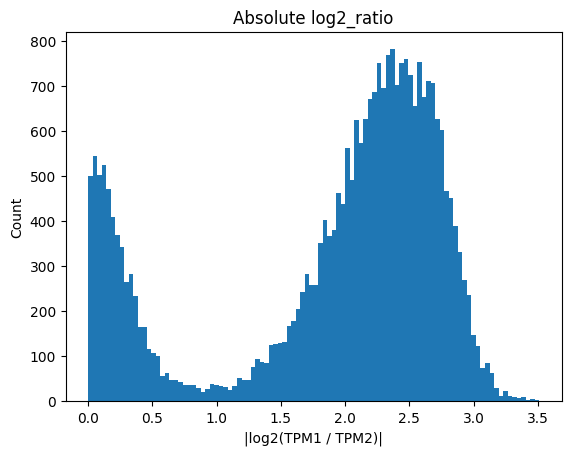

In [6]:
filtrator = ThresholdFiltrator(log2ratio)
filtrator()

##### Estimate recommended filtering thresholds based on the fraction of transcript pairs exceeding each cutoff.

In [9]:
recommendation, thresholds = filtrator.recommend_threshold(cutoff=0.5)

print(f'Recommended threshold:{recommendation[1]}, \n {thresholds}')

Recommended threshold:1.0, 
    threshold  cross-contamination_frac
0        0.0                  1.000000
1        0.5                  0.826889
2        1.0                  0.802829
3        1.5                  0.768327
4        2.0                  0.622063
5        2.5                  0.282544


##### Obtain final list of transcripts to remove for selected threshold

In [10]:
to_remove = filtrator.filter(threshold=1.25)

print(to_remove.head())
print(len(to_remove))

0     Pele_DN35713_c0_g1
1    Pdum_DN257405_c0_g1
2     Pdum_DN17763_c0_g1
3    Pele_DN121075_c1_g1
4    Pele_DN234884_c0_g1
dtype: object
22483


In [12]:
print(f"Total transcript pairs: {len(log2ratio)}")
print(f"Potential cross-contaminants: {len(to_remove)}")

Total transcript pairs: 28346
Potential cross-contaminants: 22483
